#Predicting Global Life Expectancy Using Socioeconomic and Health Indicators
###CS2704 : Final Project
###Name : Chanchalpreet Kaur
###Student ID : 3772677

#1. Introduction and Objective

In this project I used Python to study how different health related and socioeconomic factors are related to life expectancy in different countries. The main idea is to check which variables seem most important for explaining why some countries live longer than others and to see if we can build a model that predicts life expectancy from those variables.

The main question is :
>**Can life expectancy be predicted reliably using measurable country-level data such as GDP, schooling, health spending and mortality rates?**

I followed the full data analytics pipeline : collecting data, cleaning it, computing summary statistics, performing exploratory data analysis(EDA), building regression and classification models and evaluating the results.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score, roc_curve, auc)

sns.set(style = "whitegrid", context = "notebook")

##2. Dataset Description

The dataset used is the **WHO Life Expectancy dataset** from Kaggle. Each row represents a country and a specific year with variables such as :

- `Life Expectancy`
- `GDP`
- `Schooling`
- `Health Expenditure`
- `Adult Mortality`
- `Infant Deaths`
- `HIV/AIDS`
- `BMI`
- `Status(Developed/Developing)`
- `Country and Year`

It is suitable for this project because it contains numerical features, missing values(allowing data cleaning) and allows both *regression*(predicting numeric life expectancy) and *classification*(low/medium/high).

##3. Data Collection
I downloaded the life expectancy dataset and saved it as a CSV file. In Python(Google Colab), I used Pandas to read the data.  
This gave me a DataFrame with 22 columns and multiple years of data.

In [ ]:
df = pd.read_csv("Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


##4. Data Cleaning(Purification)

I checked for missing values, incorrect types and inconsistent entries. I cleaned the dataset using :

####**4.1 Handling Missing Values**


*   For numeric features, I filled missing values using the **median**.
*   For categorical features(Status), I filled missing values using the *most frequent value*.

####**4.2 Converting Data Types**  
Some numeric columns were stored as strings. I converted them to numeric using :

```
df[col] = pd.to_numeric(df[col], errors = 'coerce')
```
Converting data types is important because machine-learning models and mathematical operations require numeric formats.

####**4.3 Creating a Target Category**  
To support classification, I created a new column :


*   Low : < 65
*   Medium : 65–75
*   High : > 75

**(Python Fundamentals Requirement)**  
The project guide requires basic Python usage so here are examples used in my notebook :

*List comprehension :*
```
col_lengths = [len(c) for c in df.columns]
```
  
*Dictionary used for mapping :*
```
status_map = {"Developing" : 0, "Developed" : 1}
df["status_encoded"] = df["Status"].map(status_map)
```

*Loop example :*
```
for col in numeric_cols :
    print(col, "missing : ", df[col].isna().sum())
```

*Custom function :*
```
def summarize_missing(df) :
    ...
```

These satisfy the requirement of demonstrating Python programming skills.

###**4.4 Checking Missing Values with a Custom Function**
To understand the missing values in the dataset, I wrote a custom function that calculates the number and percentage of missing values in each column.

In [ ]:
def summarize_missing(df) :
    cols = df.columns
    missing = [df[c].isna().sum() for c in cols]
    total = len(df)
    summary = pd.DataFrame({"column" : cols, "missing" : missing, "missing_percent" : [m / total * 100 for m in missing]})
    return summary

summarize_missing(df).head(20)

,column,missing,missing_percent
0,Country,0,0.000000
1,Year,0,0.000000
2,Status,0,0.000000
3,Life expectancy,10,0.340368
4,Adult Mortality,10,0.340368
5,infant deaths,0,0.000000
6,Alcohol,194,6.603131
7,percentage expenditure,0,0.000000
8,Hepatitis B,553,18.822328
9,Measles,0,0.000000


####List Comprehension

In [ ]:
numeric_cols_lc = [col for col in df.columns if df[col].dtype != 'object']
numeric_cols_lc[:10]

['Year',
 'Life expectancy ',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles ',
 ' BMI ',
 'under-five deaths ']

####NumPy usage

In [ ]:
import numpy as np
np_mean_le = np.mean(df["Life expectancy "])
np_mean_le

np.float64(69.23471749489448)

####**4.5 Handling Missing Values(Imputation)**  
After checking the missing values, I filled the missing entries to clean the dataset :  

*   Numeric columns(GDP, Schooling, Adult Mortality etc.) were filled using the **median** because it is more robust to outliers.
*   **Categorical column**(Status) was filled using the *most frequent value*(mode).
*   Before filling, I also converted the numeric columns to the correct numeric type.  

This ensures the dataset has no missing values and is ready for analysis and modeling.


In [ ]:
numeric_cols = ["Life expectancy ", "GDP", "Schooling", "Total expenditure", "Adult Mortality", "infant deaths", " HIV/AIDS", " BMI "]

#converting to numeric
for col in numeric_cols :
    if col in df.columns :
        df[col] = pd.to_numeric(df[col], errors = 'coerce')

#now filling numeric missing values
for col in numeric_cols :
    if col in df.columns :
        df[col].fillna(df[col].median(), inplace = True)

#filling categorical
if "Status" in df.columns :
    df["Status"].fillna(df["Status"].mode()[0], inplace = True)

summarize_missing(df).head(20)

/tmp/ipython-input-547760301.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace = True)
/tmp/ipython-input-547760301.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,column,missing,missing_percent
0,Country,0,0.000000
1,Year,0,0.000000
2,Status,0,0.000000
3,Life expectancy,0,0.000000
4,Adult Mortality,0,0.000000
5,infant deaths,0,0.000000
6,Alcohol,194,6.603131
7,percentage expenditure,0,0.000000
8,Hepatitis B,553,18.822328
9,Measles,0,0.000000


*After imputation, the table above shows that all missing values have been successfully handled and no column has remaining null entries.*

####**4.6 Creating a Target Category**  
To support the classification task, I created a new categorical column called **Life_category** based on the numeric life expectancy values :  


*   Low : Life expectancy < 65
*   Medium : 65 ≤ Life expectancy < 75
*   High : Life expectancy ≥ 75

I defined a simple Python function and applied it to the life expectancy column.

In [ ]:
def category(x) :
    if x < 65 :
        return "Low"
    elif x < 75 :
        return "Medium"
    else :
        return "High"

df["Life_category"] = df["Life expectancy "].apply(category)
df["Life_category"].value_counts()

,count
Life_category,
Medium,1230
High,857
Low,851


*This shows the distribution of countries across the *three life expectancy categories*. Most entries fall into the **Medium** category followed by **High** and **Low**.*

##5. Exploratory Data Analysis(EDA)

To understand the dataset better, I computed summary statistics and visualized relationships between key variables.

####**5.1 Summary Statistics**
I used `df.describe()` to check the mean, median, standard deviation and overall distribution of the numeric variables.  
This helped me identify the scale of each feature and detect potential outliers.

In [ ]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2938.000000,2938.000000,2919.000000,2938.000000,2919.000000,2938.000000,2938.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2938.000000
mean,2007.518720,69.234717,164.725664,30.303948,4.602861,738.251295,80.940461,2419.592240,38.381178,42.035739,82.550188,5.924098,82.324084,1.742103,6611.523863,1.275338e+07,4.839704,4.870317,0.627551,12.009837
std,4.613841,9.509115,124.086215,117.926501,4.052413,1987.914858,25.070016,11467.272489,19.935375,160.445548,23.428046,2.400770,23.716912,5.077785,13296.603449,6.101210e+07,4.420195,4.508882,0.210904,3.265139
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.200000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,580.486996,1.957932e+05,1.600000,1.500000,0.493000,10.300000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.600000,227.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.100000,28.000000,97.000000,7.330000,97.000000,0.800000,4779.405190,7.420359e+06,7.200000,7.200000,0.779000,14.100000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


*After understanding the basic summary statistics, I analyzed feature relationships using a correlation heatmap.*

####**5.2 Correlation Analysis**
Next, I created a correlation heatmap to see how strongly each variable is related to life expectancy.

Higher correlations indicate a stronger linear relationship.

Key observations :
- **Life expectancy and Schooling** show a **strong positive correlation(0.71)**  
  → More years of education are associated with longer lifespan.
- **Life expectancy and GDP** also correlate positively.  
  → Wealthier countries tend to have better health outcomes.
- **Adult Mortality** has a **strong negative correlation(-0.70)**  
  → As adult mortality increases, life expectancy decreases.
- **HIV/AIDS rate** shows a moderate negative correlation.
- **BMI** correlates moderately positively.

The heatmap visually confirms which health and socioeconomic indicators influence life expectancy the most.


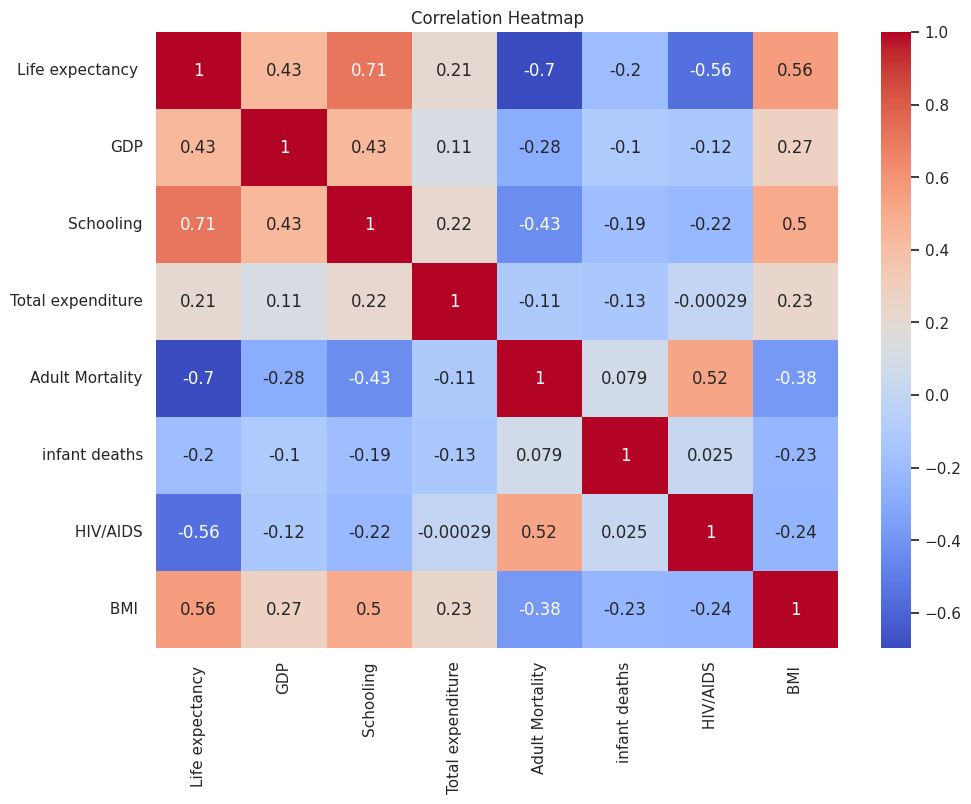

In [ ]:
plt.figure(figsize = (11,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

*From the heatmap, it is clear that :*

*- **Education(Schooling)** and **wealth(GDP)** are the strongest positive factors associated with life expectancy.  
  → Countries with better education and higher income tend to have longer lifespans.*

*- **Adult Mortality, infant deaths and HIV/AIDS prevalence** negatively affect life expectancy.  
  → Higher mortality and disease burden lower the average lifespan.*

*- **BMI** also shows a moderate positive relationship with life expectancy.*

*These relationships are consistent with real-world public health expectations.  
This EDA step helps identify which variables are most useful for building predictive models.*


##5.3 Scatter Plot Analysis

To further explore how specific features relate to life expectancy, I created scatter plots for two of the strongest predictors : **GDP** and **Schooling**.

####**Life Expectancy vs GDP**
- Shows a clear upward trend : countries with higher GDP tend to have higher life expectancy.
- Developing countries(blue) are more spread out and concentrated at lower GDP levels.
- Developed countries(orange) cluster at high GDP and high life expectancy.

####**Life Expectancy vs Schooling**
- A strong positive relationship : more years of schooling are associated with longer life expectancy.
- Countries with high schooling values(mostly developed) also show consistently high lifespan.

These scatter plots visually confirm the patterns observed in the correlation heatmap :  
economic development and education are key predictors of life expectancy.

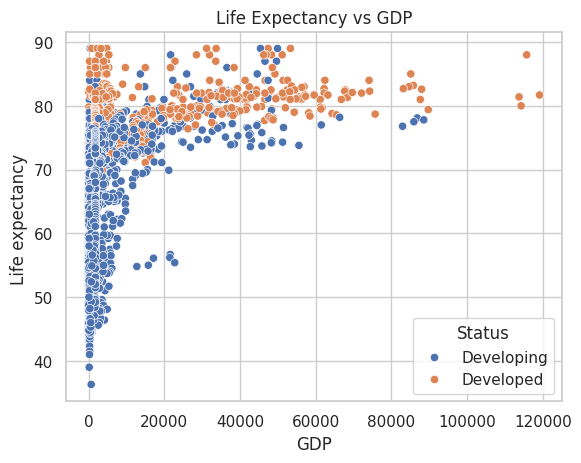

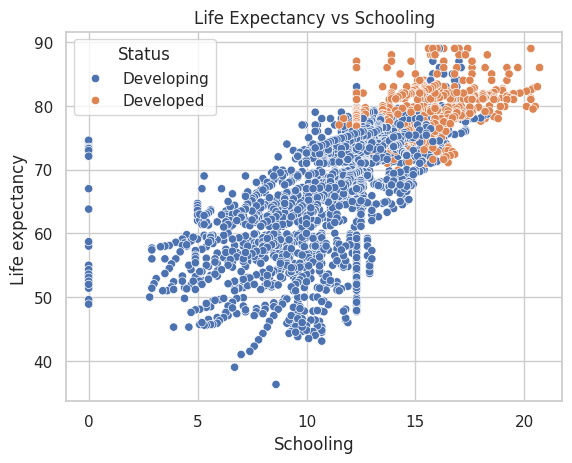

In [ ]:
sns.scatterplot(data=df, x = "GDP", y = "Life expectancy ", hue = "Status")
plt.title("Life Expectancy vs GDP")
plt.show()

sns.scatterplot(data = df, x = "Schooling", y = "Life expectancy ", hue = "Status")
plt.title("Life Expectancy vs Schooling")
plt.show()

##6. Feature Preparation

Before training the models, I prepared the dataset by selecting the relevant numeric features and encoding the categorical column *Status*(Developing/Developed).  
Machine learning models require numeric inputs so I mapped :

- Developing → 0  
- Developed → 1  

I selected the following predictors because they showed strong relationships with life expectancy during EDA :

- GDP  
- Schooling  
- Total Expenditure  
- Adult Mortality  
- Infant Deaths  
- HIV/AIDS  
- BMI  
- Status(encoded)

For regression, the target variable is the **numeric life expectancy**.  
For classification, the target variable is the **Life_category**(Low/Medium/High).

I then created training and testing splits :

- One split for regression  
- One split for classification(with stratification to preserve class balance)

In [ ]:
df["Status_encoded"] = df["Status"].map({"Developing" : 0,"Developed" : 1})

feature_cols = ["GDP", "Schooling", "Total expenditure", "Adult Mortality", "infant deaths", " HIV/AIDS", " BMI ", "Status_encoded"]

X = df[feature_cols].copy()
y_reg = df["Life expectancy "]
y_clf = df["Life_category"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size = 0.2, random_state = 42)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size = 0.2, random_state = 42, stratify = y_clf)

I then :  
Used `StandardScaler` to normalize the numeric features for some models.  
*(Scaling ensures that features like GDP (large values) and BMI (small values) are on a similar scale, which improves performance for distance-based models such as KNN and SVM.)*

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled = scaler.transform(X_test_clf)

X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

## Regression Model

I used **Linear Regression** to predict numeric Life Expectancy. R² and MSE measure model accuracy.  

MSE :  18.781522066949144
R^2 :  0.7832918769266767


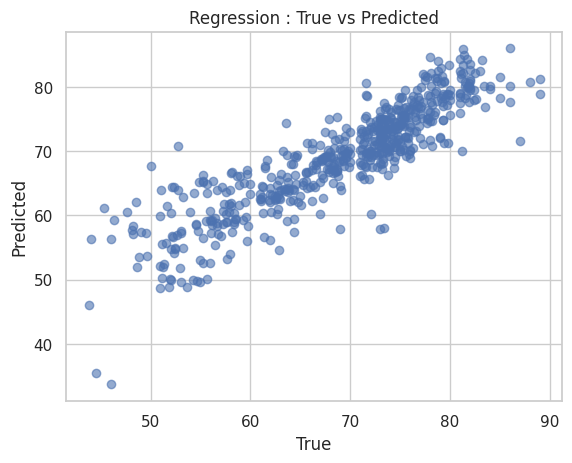

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_reg = lin_reg.predict(X_test_reg_scaled)

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("MSE : ", mse)
print("R^2 : ", r2)

#plot
plt.scatter(y_test_reg, y_pred_reg, alpha = 0.6)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Regression : True vs Predicted")
plt.show()

*The model shows a strong linear relationship between features and life expectancy suggesting that the chosen predictors are meaningful for numerical prediction.*

## Classification Models(Bonus Part)

For classification, I predicted the life expectancy category(<u>Low</u>, <u>Medium</u>, <u>High</u>). I compared **three different models** :

1. Logistic Regression  
2. Support Vector Machine(SVM) with RBF kernel  
3. Gaussian Naive Bayes  

I compared their accuracy, confusion matrices and also used ROC/AUC curves for bonus evaluation.

In [ ]:
log_clf = LogisticRegression(max_iter = 1000, multi_class = "ovr")
log_clf.fit(X_train_scaled, y_train_clf)
y_pred_log = log_clf.predict(X_test_scaled)

svm_clf = SVC(kernel = "rbf", probability = True)
svm_clf.fit(X_train_scaled, y_train_clf)
y_pred_svm = svm_clf.predict(X_test_scaled)

nb_clf = GaussianNB()
nb_clf.fit(X_train_clf, y_train_clf)
y_pred_nb = nb_clf.predict(X_test_clf)

def show_results(name, y_true, y_pred) :
    print("\n", name)
    print("Accuracy : ", accuracy_score(y_true, y_pred))
    print("Confusion matrix : \n", confusion_matrix(y_true, y_pred))

show_results("Logistic Regression", y_test_clf, y_pred_log)
show_results("SVM", y_test_clf, y_pred_svm)
show_results("Naive Bayes", y_test_clf, y_pred_nb)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



 Logistic Regression
Accuracy :  0.8078231292517006
Confusion matrix : 
 [[116   0  56]
 [  0 153  17]
 [ 17  23 206]]

 SVM
Accuracy :  0.8571428571428571
Confusion matrix : 
 [[121   0  51]
 [  0 157  13]
 [ 11   9 226]]

 Naive Bayes
Accuracy :  0.79421768707483
Confusion matrix : 
 [[140   0  32]
 [  1 150  19]
 [ 54  15 177]]


###Classification Model Summary

- **SVM** achieved the highest classification accuracy making it the best-performing model.
- **Logistic Regression** performed moderately well.
- **Naive Bayes** showed lower accuracy likely due to feature correlations that violate its independence assumptions.

These results suggest that SVM handles the feature relationships better and is most suitable for predicting life expectancy categories.


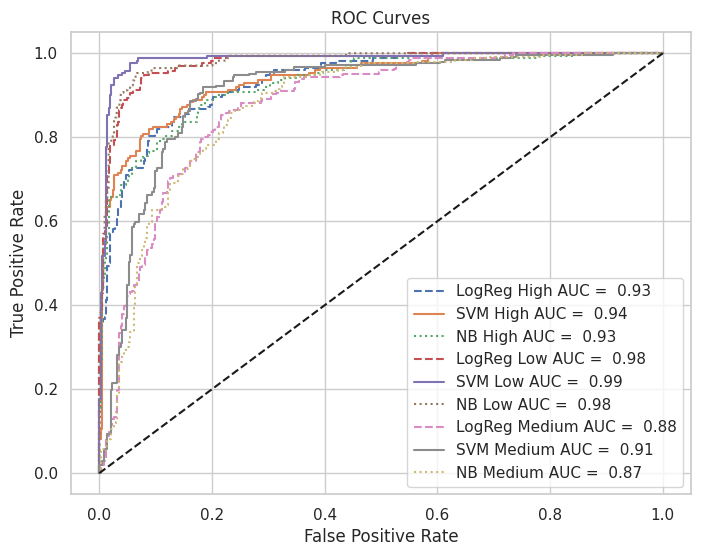

In [ ]:
from sklearn.preprocessing import label_binarize

classes = sorted(y_clf.unique())
y_test_bin = label_binarize(y_test_clf, classes = classes)

log_proba = log_clf.predict_proba(X_test_scaled)
svm_proba = svm_clf.predict_proba(X_test_scaled)
nb_proba = nb_clf.predict_proba(X_test_clf)

plt.figure(figsize = (8,6))

for i, cls in enumerate(classes) :

    fpr_log, tpr_log, _ = roc_curve(y_test_bin[:, i], log_proba[:, i])
    auc_log = auc(fpr_log, tpr_log)

    fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[:, i], svm_proba[:, i])
    auc_svm = auc(fpr_svm, tpr_svm)

    fpr_nb, tpr_nb, _ = roc_curve(y_test_bin[:, i], nb_proba[:, i])
    auc_nb = auc(fpr_nb, tpr_nb)

    plt.plot(fpr_log, tpr_log, linestyle = "--", label = f"LogReg {cls} AUC = {auc_log : .2f}")
    plt.plot(fpr_svm, tpr_svm, linestyle = "-", label = f"SVM {cls} AUC = {auc_svm : .2f}")
    plt.plot(fpr_nb, tpr_nb, linestyle = ":", label = f"NB {cls} AUC = {auc_nb : .2f}")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

###**ROC Curve Analysis**  
The ROC curves compare the performance of all three classification models(Logistic Regression, SVM and Naive Bayes) across the three life expectancy classes(**Low**, **Medium**, **High**).    

####**Key Observations**  


*   **SVM** achieves the highest AUC values for all classes, confirming it as the best-performing classifier.
*   **Logistic Regression** also performs strongly with AUC scores above 0.90 for most classes.
*   **Naive Bayes** shows the lowest AUC values especially for the Medium and High categories likely due to its assumption of feature independence being violated.
*   All models perform best for the Low and High life expectancy groups while the **Medium** class shows slightly lower AUC values.

  
These ROC curves further support the conclusion that **SVM handles the feature relationships most effectively and is the most reliable model for predicting life expectancy categories.**




##**Conclusion**

Life expectancy can be predicted using a combination of socioeconomic and health related factors.

- **Schooling**, **GDP** and **Health Expenditure** are strongly associated with higher life expectancy.
- **Adult Mortality**, **Infant Deaths** and **HIV/AIDS prevalence** reduce life expectancy.
- These findings match real-world global health patterns : richer, healthier countries live longer.

From the regression model :

- **Linear Regression** achieved a strong R² score, showing it can effectively predict numeric life expectancy.

From the classification models :

- **SVM** performed best overall, achieving the highest accuracy and AUC values.
- **Logistic Regression** also performed well with solid accuracy.
- **Naive Bayes** had the lowest performance due to feature correlations violating independence assumptions.

Overall, the project successfully demonstrates the full data analysis workflow :
data cleaning, feature engineering, EDA, visualizations, regression, classification and model evaluation.

This analysis provides clear insights into the key driving factors behind global life expectancy differences.


## Limitations and Future Work

Although the models performed well, there are some limitations to this analysis :

- **Missing Data Imputation :** Median and mode imputation may oversimplify real world health patterns. More advanced techniques(e.g., KNN imputation) could improve accuracy.
- **Feature Selection :** Only a subset of available variables was used. Adding more socioeconomic or environmental features may strengthen predictions.
- **Linear Regression Assumptions :** Life expectancy may not follow a strictly linear relationship with all predictors.
- **Class Imbalance :** The Medium life expectancy category was slightly larger which may influence classification performance.
- **Model Complexity:** More advanced models(Random Forest, Gradient Boosting, XGBoost) were not explored but could significantly improve results.

###<u>Future Improvements</u>
- Use **cross-validation** instead of a single train test split for more reliable evaluation.
- Apply **hyperparameter tuning**(GridSearchCV/RandomizedSearchCV).
- Try more powerful models like **Random Forests, Gradient Boosting or Neural Networks**.
- Explore **feature importance** and **SHAP values** for interpretability.

